# EXP-001 — динуклеотидный baseline

Первая контролируемая модель EPIC использует **ровно один категориальный
признак**: две буквы ориентированной ДНК в offsets `[-1, 0]` — букву
непосредственно перед предсказываемой позицией и букву в самой позиции.

**Гипотеза.** Локальная ориентированная пара содержит воспроизводимый
сигнал и превзойдёт константный no-skill reference на фиксированных
validation-contig.

**Меняем только одно.** Константный score заменяется на L2 logistic
regression по 16 парам `AA…TT` и общей категории `N/edge`.

**Критерий успеха до запуска.** На полном validation Average Precision
выше prevalence reference, EPIC Spearman положителен, solver сошёлся без
`ConvergenceWarning`. Официальный test не используется.


## 1. Что фиксируем до расчёта

- Split: `contig_holdout_v1`, целые contig, seed 42.
- Target: `csRNA-r1 + csRNA-r2 > 0`; исходный count остаётся только для
  вторичной ранговой метрики.
- Признак: ориентированная по цепи пара `[-1, 0]`.
- Кодирование: reference one-hot; `TT` — нулевая опорная категория,
  остальные 15 канонических пар и `N/edge` дают 16 столбцов.
- Candidate: `LogisticRegression`, L2, `C=1`, solver `lbfgs`.
- Reference: одинаковый score для всех строк.
- Метрики: полный validation AP и EPIC Spearman по положительным target.

Здесь нет Optuna, подбора threshold или выбора по validation. Этот запуск
должен дать честную первую точку отсчёта для следующих экспериментов.


In [1]:
from pathlib import Path
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").is_file()
    and (candidate / "src/ml_project").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project.epic_baseline import (
    DinucleotideBaselineConfig,
    aggregate_training_data,
    category_summary,
    coefficient_table,
    evaluate_dinucleotide_baseline,
    fit_dinucleotide_baseline,
    load_baseline_sequences,
    split_category_counts,
)
from ml_project.epic_data import ensure_prepared_split
from ml_project.epic_experiment import (
    ExperimentSpec,
    build_run_record,
    save_run_record,
)
from ml_project.sequence_features import DINUCLEOTIDE_LABELS

SPEC = ExperimentSpec(
    experiment_id="EXP-001",
    title="Динуклеотидный baseline",
    hypothesis=(
        "Ориентированная пара DNA [-1,0] содержит воспроизводимый сигнал "
        "и превосходит константный reference на validation-contig."
    ),
    changed_variable=(
        "Константный score заменён на L2 logistic regression только по "
        "17 категориям ориентированного динуклеотида."
    ),
    success_criterion=(
        "validation AP > prevalence, EPIC Spearman > 0, solver сошёлся "
        "без ConvergenceWarning"
    ),
    seed=42,
)
CONFIG = DinucleotideBaselineConfig(seed=SPEC.seed)
RUN_NAME = "run_001"
NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks/experiments/EXP-001_dinucleotide_baseline.ipynb"
)
ARTIFACT_DIR = PROJECT_ROOT / "artifacts/experiments/EXP-001" / RUN_NAME
PLOT_DIR = ARTIFACT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 40)

COLORS = {"reference": "#9AA0A6", "candidate": "#1967D2"}

def show_plot(fig, filename):
    path = PLOT_DIR / filename
    fig.savefig(path, dpi=170, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    return path

display(pd.Series({
    "python": platform.python_version(),
    "executable": sys.executable,
    "experiment": SPEC.experiment_id,
    "seed": SPEC.seed,
    "run": RUN_NAME,
}, name="value").to_frame())


,value
python,3.12.14
executable,C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\...
experiment,EXP-001
seed,42
run,run_001


## 2. Единый data contract

Следующая ячейка не создаёт новое разбиение. Она загружает сохранённый
manifest, проверяет SHA-256 исходников и производных split-файлов и
показывает фактический состав train / validation / test.

В дальнейшем читаются только train-target и validation-target. У test
нет меток, и он не участвует ни в обучении, ни в выборе решения.


In [2]:
split = ensure_prepared_split(PROJECT_ROOT)

display(split.contig_assignment.sort_values(["split", "contig"]))
display(split.summary)
print("Split version:", split.config.split_version)
print("Split seed:", split.config.seed)


,contig,split,source_split
12,NC_064037.1,test,test
13,NC_064044.1,test,test
14,NC_064046.1,test,test
1,NC_064035.1,train,train
2,NC_064036.1,train,train
3,NC_064038.1,train,train
4,NC_064039.1,train,train
5,NC_064040.1,train,train
8,NC_064043.1,train,train
9,NC_064045.1,train,train


,split,contigs,intervals_both_strands,whitelist_bp,position_strand_count,percent_of_all_positions,positive_positions,negative_positions,positive_percent
0,train,9,168998,114032080,228064160,59.316784,170443.0,227893717.0,0.074735
1,validation,3,60386,41903743,83807486,21.797334,56205.0,83751281.0,0.067064
2,test,3,54846,36306695,72613390,18.885882,NaN,NaN,NaN


Split version: contig_holdout_v1
Split seed: 42


## 3. Почему 228 млн строк можно точно свернуть в 34

У модели всего **17 возможных входов**:

- 16 пар из `A/C/G/T`: `AA, AC, …, TT`;
- одна общая категория `N/edge`, если хотя бы одна буква неизвестна либо
  контекст выходит за край contig.

Все строки одной категории имеют абсолютно одинаковый вектор признаков.
Поэтому для каждой категории достаточно двух строк: `target=0` и
`target=1`, а их `sample_weight` равен числу представленных позиций с
поправкой `class_weight="balanced"`.

Получается `17 × 2 = 34` строки для solver. Это **не subsampling**:
последовательность всё равно сканируется целиком один раз, а взвешенная
log-loss и её градиент точно совпадают с развёрнутым датасетом. Такое
сжатие возможно именно потому, что в EXP-001 только один признак с низкой
кардинальностью.


In [3]:
sequences, fasta_alphabet = load_baseline_sequences(split)

train_totals, train_positives = split_category_counts(
    split, sequences, "train"
)
validation_totals, validation_positives = split_category_counts(
    split, sequences, "validation"
)

count_audit = pd.DataFrame([
    {
        "split": "train",
        "all_position_strand": int(train_totals["total_positions"].sum()),
        "positive_position_strand": len(train_positives),
        "contigs": train_totals["contig"].nunique(),
        "categories": train_totals.loc[
            train_totals["total_positions"] > 0, "category"
        ].nunique(),
    },
    {
        "split": "validation",
        "all_position_strand": int(validation_totals["total_positions"].sum()),
        "positive_position_strand": len(validation_positives),
        "contigs": validation_totals["contig"].nunique(),
        "categories": validation_totals.loc[
            validation_totals["total_positions"] > 0, "category"
        ].nunique(),
    },
])
display(count_audit)

expected = split.summary.set_index("split")
for row in count_audit.itertuples(index=False):
    assert row.all_position_strand == int(
        expected.loc[row.split, "position_strand_count"]
    )
    assert row.positive_position_strand == int(expected.loc[row.split, "positive_positions"])
assert tuple(DINUCLEOTIDE_LABELS)[-1] == "N/edge"
print("Audit passed: ни одна train/validation позиция не потеряна.")


,split,all_position_strand,positive_position_strand,contigs,categories
0,train,228064160,170443,9,17
1,validation,83807486,56205,3,17


Audit passed: ни одна train/validation позиция не потеряна.


## 4. Что модель видит в train

`positive_rate` — доля положительных среди всех позиций данной пары.
`enrichment` делит эту долю на общую train-prevalence. Например,
enrichment `2.9×` означает: положительный target у этой пары встречается
примерно в 2.9 раза чаще, чем у случайной train-позиции. Это ассоциация,
а не причинный эффект.


In [4]:
train_category_summary = category_summary(train_totals, train_positives)
train_prevalence = (
    train_category_summary["positive_positions"].sum()
    / train_category_summary["total_positions"].sum()
)
display(
    train_category_summary.sort_values("enrichment", ascending=False)
    .style.format({
        "positive_rate": "{:.7f}",
        "enrichment": "{:.3f}×",
    })
)
print(f"Train prevalence: {train_prevalence:.9f}")


,category_code,category,total_positions,positive_positions,read_count_sum,negative_positions,positive_rate,enrichment
4,4,CA,15017204,32584,451879,14984620,0.0021698,2.903×
6,6,CG,7472366,10865,143956,7461501,0.0014540,1.946×
12,12,TA,16205488,22686,302534,16182802,0.0013999,1.873×
8,8,GA,13229546,14866,97477,13214680,0.0011237,1.504×
14,14,TG,15019881,16295,919298,15003586,0.0010849,1.452×
10,10,GG,9990982,6110,30323,9984872,0.0006116,0.818×
2,2,AG,13442948,8047,29469,13434901,0.0005986,0.801×
7,7,CT,13441887,7599,69736,13434288,0.0005653,0.756×
0,0,AA,23634607,13323,62113,23621284,0.0005637,0.754×
13,13,TC,13231627,7090,131348,13224537,0.0005358,0.717×


Train prevalence: 0.000747347


In [5]:
aggregate_rows, encoded_aggregate = aggregate_training_data(
    train_category_summary, CONFIG
)

aggregate_audit = pd.Series({
    "solver_rows": len(aggregate_rows),
    "feature_columns": encoded_aggregate.matrix.shape[1],
    "represented_positions": int(aggregate_rows["population_count"].sum()),
    "represented_positives": int(
        aggregate_rows.loc[
            aggregate_rows["target"] == 1, "population_count"
        ].sum()
    ),
    "negative_weight_sum": aggregate_rows.loc[
        aggregate_rows["target"] == 0, "sample_weight"
    ].sum(),
    "positive_weight_sum": aggregate_rows.loc[
        aggregate_rows["target"] == 1, "sample_weight"
    ].sum(),
}, name="value")
display(aggregate_audit.to_frame())
display(aggregate_rows.head(8))

assert len(aggregate_rows) == 34
assert int(aggregate_rows["population_count"].sum()) == int(
    train_totals["total_positions"].sum()
)


,value
solver_rows,34.0
feature_columns,16.0
represented_positions,228064160.0
represented_positives,170443.0
negative_weight_sum,114032080.0
positive_weight_sum,114032080.0


,category_code,category,target,population_count,class_multiplier,sample_weight
0,0,AA,0,23621284,0.500374,1.181948e+07
1,0,AA,1,13323,669.033519,8.913534e+06
2,1,AC,0,12654022,0.500374,6.331743e+06
3,1,AC,1,3939,669.033519,2.635323e+06
4,2,AG,0,13434901,0.500374,6.722475e+06
5,2,AG,1,8047,669.033519,5.383713e+06
6,3,AT,0,18345865,0.500374,9.179793e+06
7,3,AT,1,5612,669.033519,3.754616e+06


## 5. Обучение logistic regression

У `lbfgs` нет настраиваемого `learning_rate`: solver сам выбирает длину
шага во внутреннем line search. Настраиваемые здесь величины — сила L2
(`C`), точность остановки (`tol`) и лимит итераций (`max_iter`). В
baseline они заранее зафиксированы, а не подобраны по validation.

Важное ограничение визуализации: scikit-learn не возвращает историю
objective для каждой внутренней итерации `lbfgs`, поэтому честной кривой
**loss vs epoch** здесь нет. Ниже показаны доступные диагностики
сходимости; рисовать выдуманную loss-кривую нельзя.


In [6]:
fit = fit_dinucleotide_baseline(train_category_summary, CONFIG)
display(fit.fit_report.T.rename(columns={0: "value"}))

fit_row = fit.fit_report.iloc[0]
assert bool(fit_row["converged"])
assert fit_row["warnings"] == ""


,value
solver,lbfgs
penalty,l2
C,1.0
tol,0.0001
iterations,15
max_iter,350
converged,True
fit_seconds,0.094
aggregate_rows,34
represented_positions,228064160


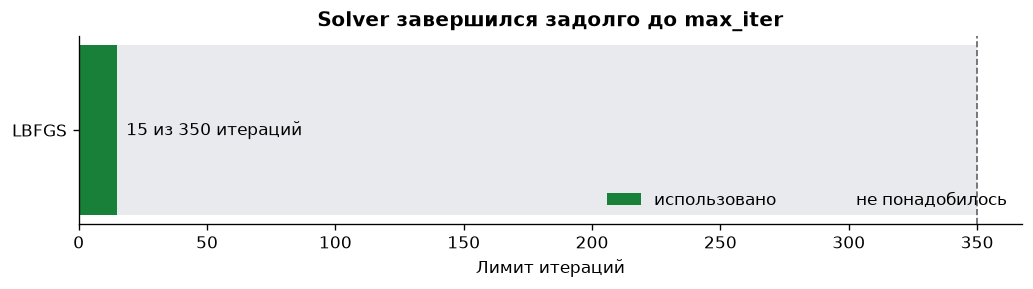

WindowsPath('D:/Projects/EPIC/EPIC/artifacts/experiments/EXP-001/run_001/plots/01_convergence.png')

In [7]:
used = int(fit_row["iterations"])
budget = int(fit_row["max_iter"])

fig, ax = plt.subplots(figsize=(8.5, 2.3), layout="constrained")
ax.barh(["LBFGS"], [used], color="#188038", label="использовано")
ax.barh(
    ["LBFGS"], [budget - used], left=[used], color="#E8EAED",
    label="не понадобилось"
)
ax.axvline(budget, color="#5F6368", linestyle="--", linewidth=1)
ax.text(used + budget * 0.01, 0, f"{used} из {budget} итераций", va="center")
ax.set(xlabel="Лимит итераций", title="Solver завершился задолго до max_iter")
ax.legend(frameon=False, ncol=2, loc="lower right")
show_plot(fig, "01_convergence.png")


## 6. Полная validation-оценка

AP вычисляется точно по всем validation-позициям, а не по выборке.
Поскольку score постоянен внутри категории, одинаковые scores
обрабатываются одной threshold-группой.

EPIC Spearman считается только среди положительных позиций: dense rank
pooled count коррелируется с dense rank score. У константного reference
ранжирования нет; в таблице для сравнения записан `0` по явной конвенции
официального fast-score, а не как математически определённая корреляция.


In [8]:
evaluation = evaluate_dinucleotide_baseline(
    validation_totals,
    validation_positives,
    fit,
    CONFIG,
)
display(
    evaluation.metric_summary.style.format({
        "reference": "{:.9f}",
        "candidate": "{:.9f}",
        "delta": "{:+.9f}",
    })
)

metric_by_name = evaluation.metric_summary.set_index("metric")
reference_ap = float(metric_by_name.loc["Average Precision", "reference"])
candidate_ap = float(metric_by_name.loc["Average Precision", "candidate"])
candidate_spearman = float(metric_by_name.loc["EPIC Spearman", "candidate"])
ap_ratio = candidate_ap / reference_ap

display(Markdown(
    f"**Итог:** AP вырос с `{reference_ap:.9f}` до `{candidate_ap:.9f}` "
    f"(`{ap_ratio:.2f}×`, delta `{candidate_ap-reference_ap:+.9f}`); "
    f"EPIC Spearman = `{candidate_spearman:.6f}`."
))


,metric,direction,reference,candidate,delta,support,positive_support
0,Average Precision,maximize,0.000670644,0.001330258,+0.000659614,83807486,56205
1,EPIC Spearman,maximize,0.000000000,0.090720285,+0.090720285,56205,56205


**Итог:** AP вырос с `0.000670644` до `0.001330258` (`1.98×`, delta `+0.000659614`); EPIC Spearman = `0.090720`.

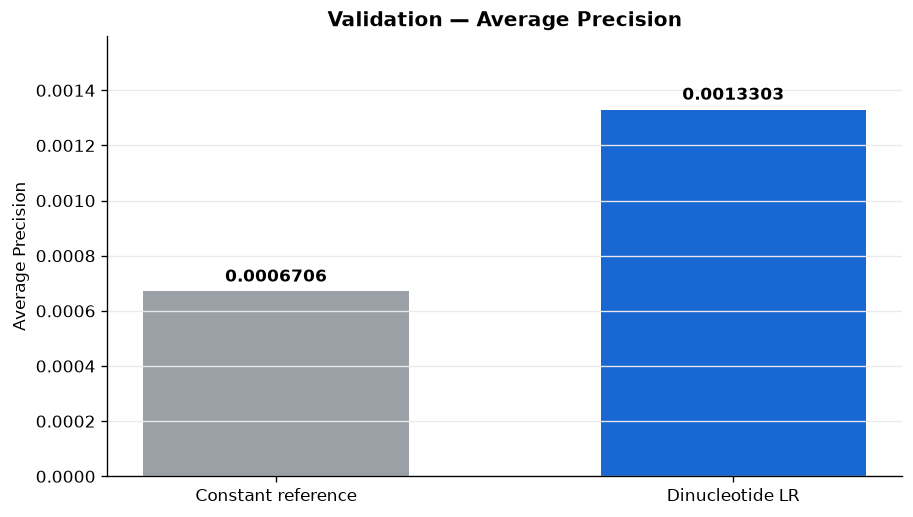

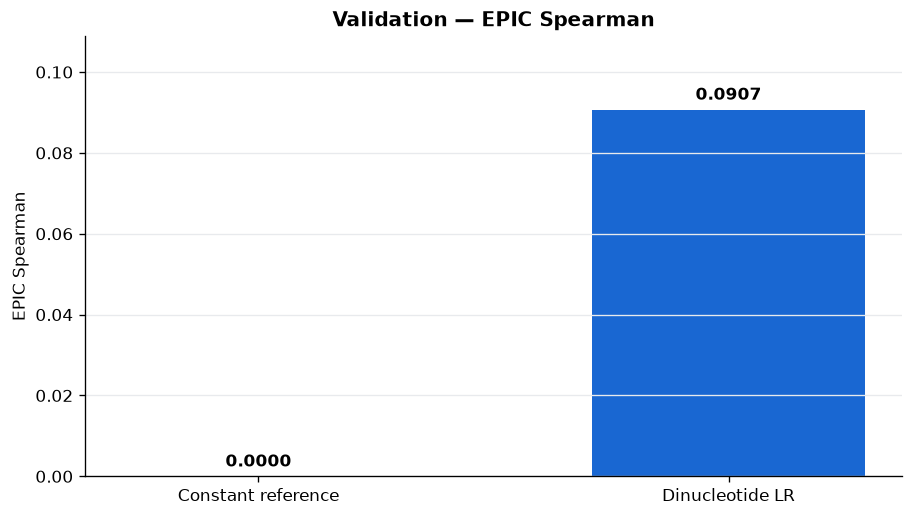

In [9]:
def metric_bar(metric, filename, decimals):
    row = metric_by_name.loc[metric]
    values = [float(row["reference"]), float(row["candidate"])]
    labels = ["Constant reference", "Dinucleotide LR"]
    colors = [COLORS["reference"], COLORS["candidate"]]
    fig, ax = plt.subplots(figsize=(7.5, 4.2), layout="constrained")
    bars = ax.bar(labels, values, color=colors, width=0.58)
    margin = max(values) * 0.20 if max(values) else 0.1
    ax.set_ylim(0, max(values) + margin)
    ax.set_ylabel(metric)
    ax.set_title(f"Validation — {metric}")
    ax.grid(axis="y", color="#E8EAED", linewidth=0.8)
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + margin * 0.08,
            f"{value:.{decimals}f}",
            ha="center",
            va="bottom",
            fontweight="bold",
        )
    show_plot(fig, filename)

metric_bar("Average Precision", "02_average_precision.png", 7)
metric_bar("EPIC Spearman", "03_epic_spearman.png", 4)


### Precision–Recall, а не accuracy

Положительный класс крайне редкий, поэтому accuracy вводила бы в
заблуждение. Горизонтальная линия — prevalence: ожидаемый AP
константного/случайного ранжирования. Ступеней немного, потому что модель
имеет только 17 возможных score-уровней.


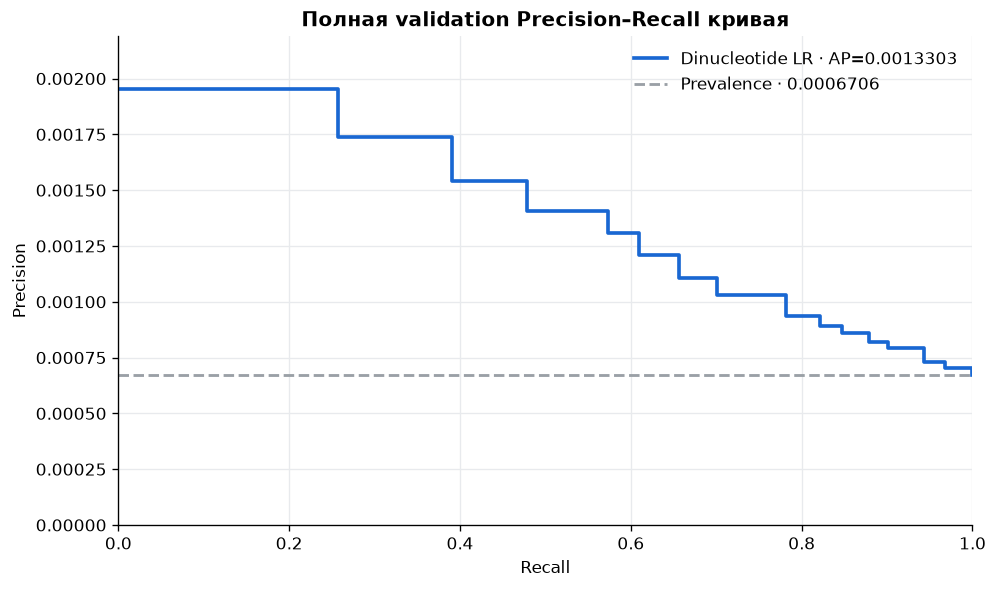

WindowsPath('D:/Projects/EPIC/EPIC/artifacts/experiments/EXP-001/run_001/plots/04_precision_recall.png')

In [10]:
pr = evaluation.precision_recall.sort_values("recall")
fig, ax = plt.subplots(figsize=(8.2, 4.8), layout="constrained")
ax.step(
    np.r_[0.0, pr["recall"].to_numpy()],
    np.r_[pr["precision"].iloc[0], pr["precision"].to_numpy()],
    where="post",
    color=COLORS["candidate"],
    linewidth=2.2,
    label=f"Dinucleotide LR · AP={candidate_ap:.7f}",
)
ax.axhline(
    reference_ap,
    color=COLORS["reference"],
    linestyle="--",
    linewidth=1.7,
    label=f"Prevalence · {reference_ap:.7f}",
)
ax.set(
    xlim=(0, 1),
    ylim=(0, max(pr["precision"].max(), reference_ap) * 1.12),
    xlabel="Recall",
    ylabel="Precision",
    title="Полная validation Precision–Recall кривая",
)
ax.grid(color="#E8EAED", linewidth=0.8)
ax.legend(frameon=False)
show_plot(fig, "04_precision_recall.png")


### Устойчивость по validation-contig

Общая метрика может скрыть, что выигрыш создаёт один contig. Поэтому
каждая тонкая линия ниже соединяет reference и candidate для одного и
того же contig. Ромб показывает среднее по трём contig и не заменяет
полную pooled-метрику выше.


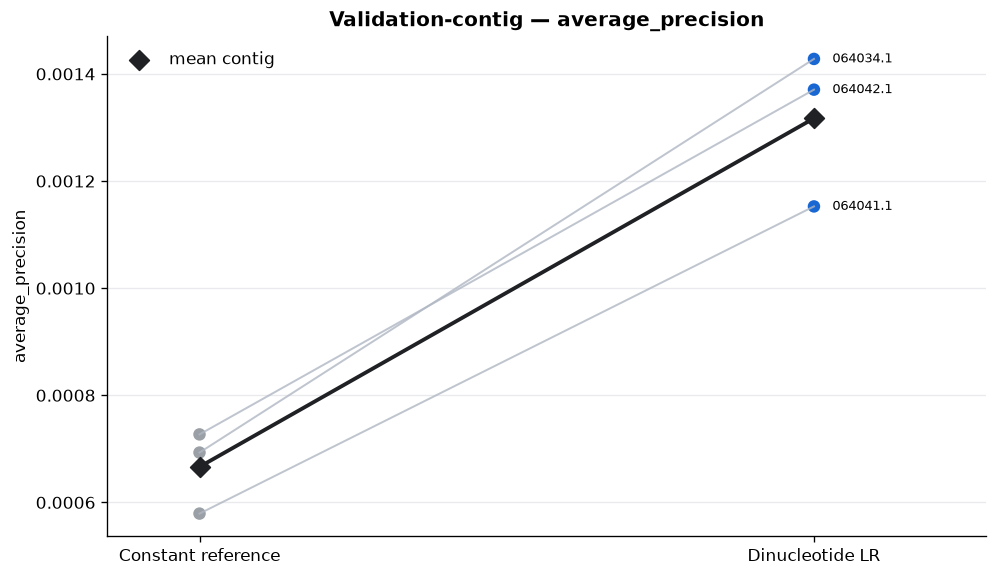

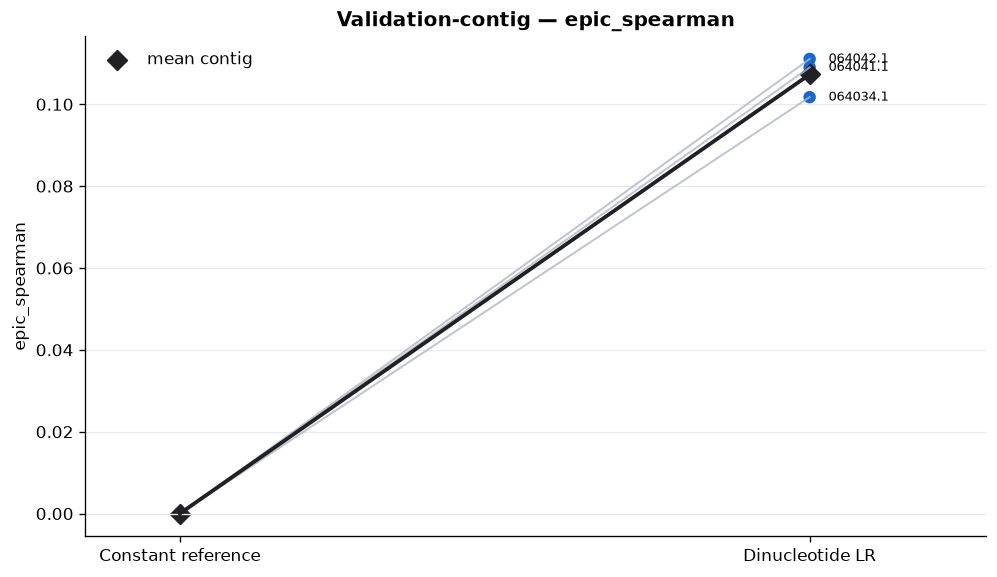

,segment,segment_value,variant,average_precision,epic_spearman,positions,positives,prevalence,unique_score_levels,metric_note
0,contig,NC_064034.1,constant_reference,0.000693,0.000000,33949114,23529,0.000693,1,constant score: AP equals prevalence; Spearman...
1,contig,NC_064034.1,dinucleotide_logistic,0.001428,0.101741,33949114,23529,0.000693,17,exact full-whitelist evaluation
2,contig,NC_064041.1,constant_reference,0.000579,0.000000,24146754,13984,0.000579,1,constant score: AP equals prevalence; Spearman...
3,contig,NC_064041.1,dinucleotide_logistic,0.001153,0.109017,24146754,13984,0.000579,17,exact full-whitelist evaluation
4,contig,NC_064042.1,constant_reference,0.000727,0.000000,25711618,18692,0.000727,1,constant score: AP equals prevalence; Spearman...
5,contig,NC_064042.1,dinucleotide_logistic,0.001371,0.111078,25711618,18692,0.000727,17,exact full-whitelist evaluation


In [11]:
per_contig = evaluation.per_contig_metrics.copy()

def paired_contig_plot(metric, filename, decimals):
    pivot = per_contig.pivot(
        index="segment_value", columns="variant", values=metric
    )
    x = np.array([0.0, 1.0])
    fig, ax = plt.subplots(figsize=(8.2, 4.7), layout="constrained")
    for contig, row in pivot.iterrows():
        y = [row["constant_reference"], row["dinucleotide_logistic"]]
        ax.plot(x, y, color="#B0B7C3", linewidth=1.2, alpha=0.8)
        ax.scatter(x, y, color=[COLORS["reference"], COLORS["candidate"]], s=42)
        ax.text(1.03, y[1], str(contig).replace("NC_", ""), va="center", fontsize=8)
    means = [
        pivot["constant_reference"].mean(),
        pivot["dinucleotide_logistic"].mean(),
    ]
    ax.plot(x, means, color="#202124", linewidth=2.3, zorder=3)
    ax.scatter(x, means, color="#202124", marker="D", s=70, label="mean contig")
    ax.set_xticks(x, ["Constant reference", "Dinucleotide LR"])
    ax.set_xlim(-0.15, 1.28)
    ax.set_ylabel(metric)
    ax.set_title(f"Validation-contig — {metric}")
    ax.grid(axis="y", color="#E8EAED", linewidth=0.8)
    ax.legend(frameon=False)
    show_plot(fig, filename)
    return pivot

contig_ap = paired_contig_plot(
    "average_precision", "05_contig_average_precision.png", 7
)
contig_spearman = paired_contig_plot(
    "epic_spearman", "06_contig_epic_spearman.png", 4
)
display(per_contig)


## 7. Вклад категорий

Коэффициент — изменение log-odds относительно опорной пары `TT` при
прочих равных. Здесь других признаков нет. Положительное значение
повышает score, отрицательное понижает; `exp(coefficient)` показан как
odds ratio относительно `TT`.

Это удобная интерпретация baseline, но не причинный вывод. Кроме того,
class balancing сдвигает intercept, поэтому сами scores не следует
читать как откалиброванные вероятности.


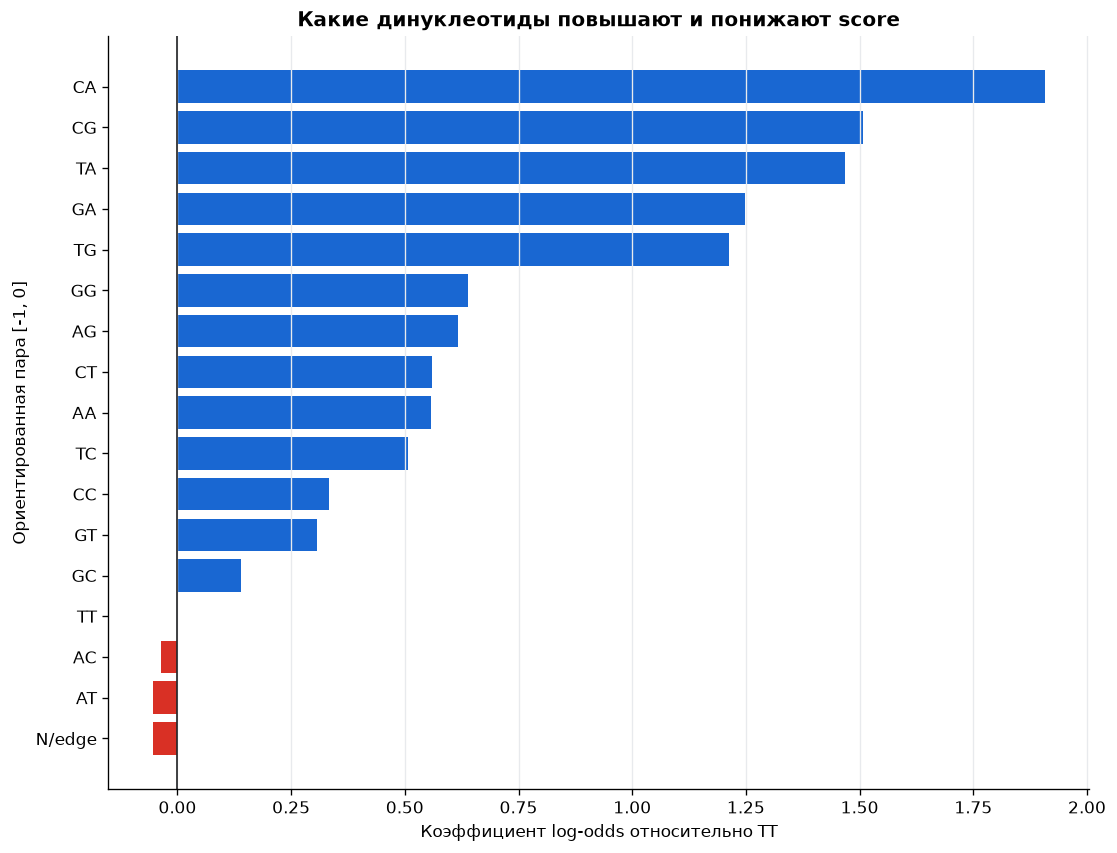

,category,feature,coefficient,odds_ratio,is_reference,positive_rate,enrichment
0,CA,"pair[-1,0]=CA",+1.9073,6.735×,False,0.0021698,2.903×
1,CG,"pair[-1,0]=CG",+1.5068,4.512×,False,0.0014540,1.946×
2,TA,"pair[-1,0]=TA",+1.4679,4.340×,False,0.0013999,1.873×
3,GA,"pair[-1,0]=GA",+1.2486,3.485×,False,0.0011237,1.504×
4,TG,"pair[-1,0]=TG",+1.2128,3.363×,False,0.0010849,1.452×
5,GG,"pair[-1,0]=GG",+0.6391,1.895×,False,0.0006116,0.818×
6,AG,"pair[-1,0]=AG",+0.6175,1.854×,False,0.0005986,0.801×
7,CT,"pair[-1,0]=CT",+0.5606,1.752×,False,0.0005653,0.756×
8,AA,"pair[-1,0]=AA",+0.5574,1.746×,False,0.0005637,0.754×
9,TC,"pair[-1,0]=TC",+0.5073,1.661×,False,0.0005358,0.717×


In [12]:
coefficients = coefficient_table(fit, CONFIG).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9.2, 7.0), layout="constrained")
colors = np.where(
    coefficients["coefficient"] >= 0, "#1967D2", "#D93025"
)
ax.barh(coefficients["category"], coefficients["coefficient"], color=colors)
ax.axvline(0, color="#202124", linewidth=1)
ax.set(
    xlabel="Коэффициент log-odds относительно TT",
    ylabel="Ориентированная пара [-1, 0]",
    title="Какие динуклеотиды повышают и понижают score",
)
ax.grid(axis="x", color="#E8EAED", linewidth=0.8)
show_plot(fig, "07_dinucleotide_coefficients.png")

category_effects = (
    coefficients.merge(
        train_category_summary[
            ["category", "positive_rate", "enrichment"]
        ],
        on="category",
        how="left",
    )
    .sort_values("coefficient", ascending=False)
    .reset_index(drop=True)
)
display(
    category_effects.style.format({
        "coefficient": "{:+.4f}",
        "odds_ratio": "{:.3f}×",
        "positive_rate": "{:.7f}",
        "enrichment": "{:.3f}×",
    })
)


## 8. Решение

Критерий применяется механически к тем значениям, которые были
зафиксированы до запуска. Baseline принимается как первая рабочая точка,
если обе метрики лучше reference и solver действительно сошёлся.

Это не означает, что `C=1` оптимально или что двух букв достаточно для
финального решения. Следующий отдельный эксперимент сможет менять ровно
один компонент — например, регуляризацию или ширину контекста — и
сравниваться с этим сохранённым baseline.


In [13]:
success_checks = pd.Series({
    "AP выше prevalence reference": candidate_ap > reference_ap,
    "EPIC Spearman положителен": candidate_spearman > 0,
    "LBFGS сошёлся": bool(fit_row["converged"]),
    "Нет ConvergenceWarning": fit_row["warnings"] == "",
}, name="passed")
display(success_checks.to_frame())

success = bool(success_checks.all())
DECISION = "adopt" if success else "iterate"
INTERPRETATION = (
    f"На полном validation динуклеотидный baseline увеличил AP с "
    f"{reference_ap:.9f} до {candidate_ap:.9f} ({ap_ratio:.2f}x) и дал "
    f"EPIC Spearman {candidate_spearman:.6f}. LBFGS сошёлся за "
    f"{int(fit_row['iterations'])} итераций без предупреждений. "
    f"Решение: {DECISION}; использовать эту модель как reference для "
    f"следующего контролируемого эксперимента."
)
display(Markdown(f"**Decision: `{DECISION}`.** {INTERPRETATION}"))


,passed
AP выше prevalence reference,True
EPIC Spearman положителен,True
LBFGS сошёлся,True
Нет ConvergenceWarning,True


**Decision: `adopt`.** На полном validation динуклеотидный baseline увеличил AP с 0.000670644 до 0.001330258 (1.98x) и дал EPIC Spearman 0.090720. LBFGS сошёлся за 15 итераций без предупреждений. Решение: adopt; использовать эту модель как reference для следующего контролируемого эксперимента.

## 9. Сохранение воспроизводимого запуска

Сохраняются таблицы, predictions только для положительных validation
позиций, PR points, коэффициенты, графики и `metadata.json` с параметрами,
метриками, SHA-256 data contract и notebook.

`run_001` намеренно не перезаписывается: после изменения параметров нужен
новый `RUN_NAME`, иначе старый и новый результат смешались бы.


In [14]:
tables = {
    "train_category_summary.csv": train_category_summary,
    "aggregate_training_rows.csv": fit.aggregate_training_rows,
    "fit_report.csv": fit.fit_report,
    "metric_summary.csv": evaluation.metric_summary,
    "per_contig_metrics.csv": evaluation.per_contig_metrics,
    "validation_category_summary.csv": evaluation.category_summary,
    "precision_recall.csv": evaluation.precision_recall,
    "coefficients.csv": category_effects,
}
for filename, table in tables.items():
    table.to_csv(ARTIFACT_DIR / filename, index=False)
evaluation.positive_predictions.to_csv(
    ARTIFACT_DIR / "validation_positive_predictions.csv.gz",
    index=False,
    compression="gzip",
)

METRICS = {
    "reference_average_precision": reference_ap,
    "candidate_average_precision": candidate_ap,
    "delta_average_precision": candidate_ap - reference_ap,
    "reference_epic_spearman": 0.0,
    "candidate_epic_spearman": candidate_spearman,
    "delta_epic_spearman": candidate_spearman,
}
EXPERIMENT_PARAMETERS = CONFIG.to_dict() | {
    "feature": "oriented DNA dinucleotide at offsets [-1, 0]",
    "categories": list(DINUCLEOTIDE_LABELS),
    "class_weight_equivalent": "balanced through exact sample weights",
    "validation_population": "all whitelist positions",
    "reference": "constant score",
    "reference_spearman_policy": "0 by explicit no-ranking convention",
}
record = build_run_record(
    SPEC,
    split,
    run_name=RUN_NAME,
    notebook_path=NOTEBOOK_PATH,
    parameters=EXPERIMENT_PARAMETERS,
    metrics=METRICS,
    interpretation=INTERPRETATION,
    decision=DECISION,
)
output = save_run_record(PROJECT_ROOT, record)

(output / "config.json").write_text(
    json.dumps(EXPERIMENT_PARAMETERS, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
print("Saved run:", output)
print("Saved files:")
for path in sorted(output.rglob("*")):
    if path.is_file():
        print(" -", path.relative_to(PROJECT_ROOT))


Saved run: D:\Projects\EPIC\EPIC\artifacts\experiments\EXP-001\run_001
Saved files:
 - artifacts\experiments\EXP-001\run_001\aggregate_training_rows.csv
 - artifacts\experiments\EXP-001\run_001\coefficients.csv
 - artifacts\experiments\EXP-001\run_001\config.json
 - artifacts\experiments\EXP-001\run_001\fit_report.csv
 - artifacts\experiments\EXP-001\run_001\metadata.json
 - artifacts\experiments\EXP-001\run_001\metric_summary.csv
 - artifacts\experiments\EXP-001\run_001\metrics.csv
 - artifacts\experiments\EXP-001\run_001\per_contig_metrics.csv
 - artifacts\experiments\EXP-001\run_001\plots\01_convergence.png
 - artifacts\experiments\EXP-001\run_001\plots\02_average_precision.png
 - artifacts\experiments\EXP-001\run_001\plots\03_epic_spearman.png
 - artifacts\experiments\EXP-001\run_001\plots\04_precision_recall.png
 - artifacts\experiments\EXP-001\run_001\plots\05_contig_average_precision.png
 - artifacts\experiments\EXP-001\run_001\plots\06_contig_epic_spearman.png
 - artifacts\expe